In [1]:
import sys                                                                                                                                                                                                        
sys.path.insert(0, '/home/svu/e1498138/emri_search/work')                                                                                                                                                   
                                                                                                                                                                                                                    
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response                                                                                                                                                 
from loglike_timemax_noise import LogLike                                                                                                                                                                           
import numpy as np                                                                                                                                                                                                  
import cupy as cp

In [2]:
use_gpu=True                                                                                                                                       
T = 3/12        # years                 
dt = 10.0       # seconds

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 5  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5                                                                                                                           
                                                                                                                                                                                                                                                                                                                                                    
                                        
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    
         

In [ ]:
params=[m1,m2,a,p0,e0,xI0,dist,qS,phiS,qK,phiK,Phi_phi0,Phi_theta0,Phi_r0]

In [ ]:
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=True,tdi_gen=1)

# no noise check

In [5]:
# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

loglike_obj = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=False,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

Delta_T for mode selection: 1577.9074881772797 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), 

In [6]:
%%time
#loglike at true param
logl_true=loglike_obj(params)
print(logl_true)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.7575, rho=0.8704
  Mode 1: <hf|hf>_timemax=3.411, rho=1.847
  Mode 2: <hf|hf>_timemax=22.68, rho=4.762
  Mode 3: <hf|hf>_timemax=29.71, rho=5.451
  Mode 4: <hf|hf>_timemax=19.27, rho=4.39
  Mode 5: <hf|hf>_timemax=8.329, rho=2.886
  Mode 6: <hf|hf>_timemax=2.804, rho=1.675
rho_m: [0.87036367 1.8469897  4.76200793 5.45064359 4.38970368 2.8859957
 1.67462553]
Dominant mode index: 3, rho: 5.451
beta=0.04985, rho_dom_M=5.451, rho_tot=9.887
X_scalar (time-maximized): 9.887
Time-maximized Log-likelihood: 9.82429
9.824290448620701
CPU times: user 180 ms, sys: 15.9 ms, total: 196 ms
Wall time: 262 ms


In [7]:
params_perturbed = list(params)                                                                                                                                                                                     
params_perturbed[0] *= 1.01                                                                                                                                                                                         
logl_perturbed = loglike_obj(params_perturbed)                                                                                                                                                                               
print(logl_perturbed)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.7244, rho=0.8511
  Mode 1: <hf|hf>_timemax=3.265, rho=1.807
  Mode 2: <hf|hf>_timemax=21.86, rho=4.675
  Mode 3: <hf|hf>_timemax=28.89, rho=5.375
  Mode 4: <hf|hf>_timemax=18.91, rho=4.348
  Mode 5: <hf|hf>_timemax=8.234, rho=2.87
  Mode 6: <hf|hf>_timemax=2.787, rho=1.67
rho_m: [0.85112378 1.80704961 4.67544642 5.37505771 4.34836793 2.86954856
 1.66951298]
Dominant mode index: 3, rho: 5.375
beta=0.05071, rho_dom_M=5.375, rho_tot=9.758
X_scalar (time-maximized): 1.769
Time-maximized Log-likelihood: 0.413006
0.41300625441772976


# check with noise/

In [8]:


loglike_obj_noise = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=True,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

[INFO] Added colored noise with seed=0
Delta_T for mode selection: 1577.9074881772797 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1)

In [9]:
#loglike at true param
logl_true_noise=loglike_obj_noise(params)
print(logl_true_noise)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.7575, rho=0.8704
  Mode 1: <hf|hf>_timemax=3.411, rho=1.847
  Mode 2: <hf|hf>_timemax=22.68, rho=4.762
  Mode 3: <hf|hf>_timemax=29.71, rho=5.451
  Mode 4: <hf|hf>_timemax=19.27, rho=4.39
  Mode 5: <hf|hf>_timemax=8.329, rho=2.886
  Mode 6: <hf|hf>_timemax=2.804, rho=1.675
rho_m: [0.87036367 1.8469897  4.76200793 5.45064359 4.38970368 2.8859957
 1.67462553]
Dominant mode index: 3, rho: 5.451
beta=0.04985, rho_dom_M=5.451, rho_tot=9.887
X_scalar (time-maximized): 11.54
Time-maximized Log-likelihood: 9.82479
9.824787657721307


In [10]:
                                                                                                                                                                                       
logl_perturbed_noise = loglike_obj_noise(params_perturbed)                                                                                                                                                                               
print(logl_perturbed_noise)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.7244, rho=0.8511
  Mode 1: <hf|hf>_timemax=3.265, rho=1.807
  Mode 2: <hf|hf>_timemax=21.86, rho=4.675
  Mode 3: <hf|hf>_timemax=28.89, rho=5.375
  Mode 4: <hf|hf>_timemax=18.91, rho=4.348
  Mode 5: <hf|hf>_timemax=8.234, rho=2.87
  Mode 6: <hf|hf>_timemax=2.787, rho=1.67
rho_m: [0.85112378 1.80704961 4.67544642 5.37505771 4.34836793 2.86954856
 1.66951298]
Dominant mode index: 3, rho: 5.375
beta=0.05071, rho_dom_M=5.375, rho_tot=9.758
X_scalar (time-maximized): 4.554
Time-maximized Log-likelihood: 2.64908
2.6490756207661392


# 2 yr with noise

In [11]:
gwf_2yr=GravWaveAnalysis(T=2, dt=dt, use_gpu=True,tdi_gen=1)
waveform_response_2yr = build_waveform_response(T=2, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    

loglike_2yr = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response_2yr,                                                                                                                                                                            
    gwf=gwf_2yr,                                                                                                                                                                                                      
    add_noise=True,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

[INFO] Added colored noise with seed=0
Delta_T for mode selection: 12623.259905418237 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1)

In [12]:
#loglike at true param
logl_2yr=loglike_2yr(params)
print(logl_2yr)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=99.83, rho=9.991
  Mode 1: <hf|hf>_timemax=803.5, rho=28.35
  Mode 2: <hf|hf>_timemax=799.6, rho=28.28
  Mode 3: <hf|hf>_timemax=342.5, rho=18.51
  Mode 4: <hf|hf>_timemax=114.5, rho=10.7
  Mode 5: <hf|hf>_timemax=33.11, rho=5.754
  Mode 6: <hf|hf>_timemax=8.555, rho=2.925
rho_m: [ 9.99140524 28.34532004 28.27725906 18.5057635  10.69914149  5.75375192
  2.92486034]
Dominant mode index: 1, rho: 28.35
beta=0.003953, rho_dom_M=28.35, rho_tot=49.95
X_scalar (time-maximized): 51
Time-maximized Log-likelihood: 48.2361
48.23613940378174


# check orthogonality

In [13]:
waveforms_per_group = []
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]
params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
waveforms = [   
    cp.array(waveform_response(*params, T=T, dt=dt, mode_selection=g, include_minus_mkn=False))                                                                                    
    for g in groups                                                                                                                                                                
]

In [14]:
n = len(groups)                                                                                                                                                                    
overlap_matrix = np.zeros((n, n))
                                                                                                                                                                                    
for i in range(n):
    for j in range(n):
        hi_f = gwf.freq_wave(waveforms[i])
        hj_f = gwf.freq_wave(waveforms[j])                                                                                                                                         
        overlap_matrix[i, j] = float(cp.real(gwf.overlap(hi_f, hj_f)))   

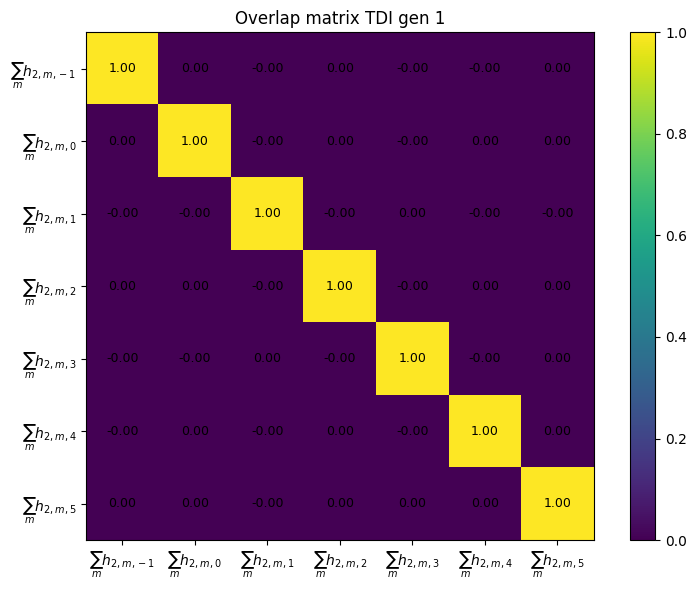

In [15]:
# Display as heatmap
labels = [                                                                                                                                                                                       
    r'$\sum_m h_{2,m,-1}$',                                                      
    r'$\sum_m h_{2,m,0}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,1}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,2}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,3}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,4}$',                                                                                                                                                                       
    r'$\sum_m h_{2,m,5}$',
]
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))                                                                                                                                             
im = ax.imshow(overlap_matrix, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(labels)                                                                                                                                
ax.set_yticks(range(n)); ax.set_yticklabels(labels)
ax.set_title('Overlap matrix TDI gen 1')                                                                                                                                          
plt.colorbar(im, ax=ax)
for i in range(n):                                                                                                                                                                 
    for j in range(n):                                                                                                                                                             
        ax.text(j, i, f'{overlap_matrix[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()                                                                                                                                                                 
plt.show() 

In [16]:
overlap_matrix

array([[ 1.00000000e+00,  1.26464643e-05, -2.37872687e-05,
         3.01229900e-06, -1.17830201e-05, -5.96478491e-06,
         4.78082078e-06],
       [ 1.26464643e-05,  1.00000000e+00, -1.14795328e-05,
         2.54980621e-05, -2.25237779e-06,  1.30099215e-05,
         9.67028997e-06],
       [-2.37872687e-05, -1.14795328e-05,  1.00000000e+00,
        -1.36683443e-05,  2.64410395e-05, -3.85352935e-06,
        -2.35003403e-05],
       [ 3.01229900e-06,  2.54980621e-05, -1.36683443e-05,
         1.00000000e+00, -4.42932159e-06,  3.57336203e-05,
         5.27622874e-05],
       [-1.17830201e-05, -2.25237779e-06,  2.64410395e-05,
        -4.42932159e-06,  1.00000000e+00, -1.08573790e-06,
         4.40413514e-05],
       [-5.96478491e-06,  1.30099215e-05, -3.85352935e-06,
         3.57336203e-05, -1.08573790e-06,  1.00000000e+00,
         4.03825551e-05],
       [ 4.78082078e-06,  9.67028997e-06, -2.35003403e-05,
         5.27622874e-05,  4.40413514e-05,  4.03825551e-05,
         1.0000000

# conditionals 2 yr

In [ ]:
  import few
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
import loglike_timemax_noise
import loglike_phasemax_noise
import loglike_pure_noise

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
T = 24/12   # 2 yr
dt = 10

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters (same as in plot_fstat_lnL_2yr)
m1 = 1e6; m2 = 1e1; a = 0.7; p0 = 9; e0 = 0.4; xI0 = 1.0
dist = 1.8; qS = np.pi; phiS = 0.; qK = 0.; phiK = 0.
Phi_phi0 = 0.4; Phi_theta0 = 0.0; Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing loglike_tm...')
loglike_tm = loglike_timemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=True,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pm...')
loglike_pm = loglike_phasemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pure...')
loglike_p = loglike_pure_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

def logden_tm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_pm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_pm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_pure(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_p(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing loglike_tm...
[INFO] Added colored noise with seed=0
Delta_T for mode selection: 12623.259905418237 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2

In [18]:
# Sanity check at true params
print(logden_tm(param_true), logden_pm(param_true), logden_pure(param_true))

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=770.3, rho=27.75
  Mode 1: <hf|hf>_timemax=6200, rho=78.74
  Mode 2: <hf|hf>_timemax=6170, rho=78.55
  Mode 3: <hf|hf>_timemax=2642, rho=51.4
  Mode 4: <hf|hf>_timemax=883.3, rho=29.72
  Mode 5: <hf|hf>_timemax=255.4, rho=15.98
  Mode 6: <hf|hf>_timemax=66.01, rho=8.125
rho_m: [27.75390344 78.73700012 78.54794182 51.4048986  29.71983749 15.98264422
  8.12461205]
Dominant mode index: 1, rho: 78.74
beta=0.0006689, rho_dom_M=78.74, rho_tot=138.8
X_scalar (time-maximized): 139.8
Time-maximized Log-likelihood: 135.393
135.3926473499691 135.43768126214826 135.43518538726332


In [19]:
# Sweep over logm2
param_idx = 1  # logm2
param_range = np.sort(np.append(np.linspace(0.99999, 1.00001, 100), param_true[param_idx]))

f_stats_tm   = np.zeros(len(param_range))
f_stats_pm   = np.zeros(len(param_range))
f_stats_pure = np.zeros(len(param_range))

for i, val in enumerate(param_range):
    p = param_true.copy()
    p[param_idx] = val
    f_stats_tm[i]   = logden_tm(p)
    f_stats_pm[i]   = logden_pm(p)
    f_stats_pure[i] = logden_pure(p)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=770.3, rho=27.75
  Mode 1: <hf|hf>_timemax=6184, rho=78.64
  Mode 2: <hf|hf>_timemax=6193, rho=78.7
  Mode 3: <hf|hf>_timemax=2636, rho=51.34
  Mode 4: <hf|hf>_timemax=883.7, rho=29.73
  Mode 5: <hf|hf>_timemax=255.4, rho=15.98
  Mode 6: <hf|hf>_timemax=66.01, rho=8.124
rho_m: [27.7546226  78.63931564 78.69641296 51.34299107 29.72702774 15.98090655
  8.1244349 ]
Dominant mode index: 2, rho: 78.7
beta=0.000667, rho_dom_M=78.7, rho_tot=138.9
X_scalar (time-maximized): 79.24
Time-maximized Log-likelihood: 30.6187
Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=770.1, rho=27.75
  Mode 1: <hf|hf>_timemax=6191, rho=78.68
  Mode 2: <hf|hf>_timemax=6181, rho=78.62
  Mode 3: <hf|hf>_timemax=2640, rho=51.38
  Mode 4: <hf|hf>_timemax=883.2, rho=29.72
  Mode 5: <hf|hf>_timemax=255.5, rho=15.98
  Mode 6: <hf|hf>_timemax=66, rho=8.124
rho_m: [27.7512025  78.68229462 78.6203526  51.38333724 29.71825922 15.98388466
  8.124

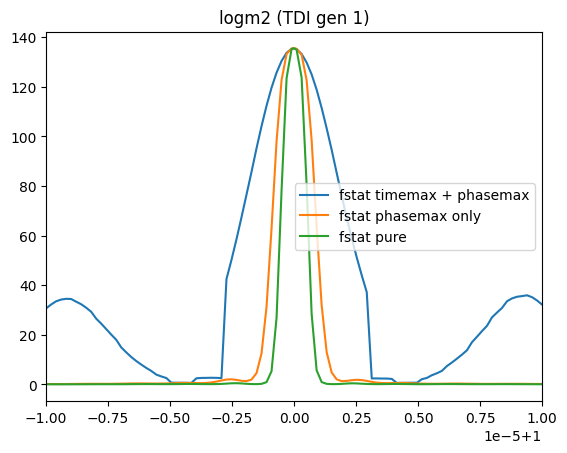

In [20]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax + phasemax')
plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.xlim(0.99999, 1.00001)
plt.title('logm2 (TDI gen 1)')
plt.legend()
plt.show()